# **Credit Card Fraud Detection Project Report**

## **Overview of the Problem**
---

Credit card fraud is a major global issue, causing significant financial losses for both financial institutions and consumers. With the rapid adoption of digital payment systems, detecting fraudulent transactions has become increasingly critical. Financial institutions process millions of transactions daily, and identifying fraud manually is impractical due to the rarity of fraudulent events and the sheer volume of data.
<br>
<br>
To address this challenge, the Credit Card Fraud Detection dataset was selected for this project. The dataset provides a realistic and challenging classification problem for machine learning algorithms, containing anonymised real transaction data to protect sensitive financial information. A key difficulty is the extreme class imbalance, where fraudulent transactions make up only a small fraction of the total data. This imbalance complicates detection for traditional methods and underscores the need for specialized machine learning approaches.
<br>
<br>
The objective of this project is to develop machine learning models capable of detecting fraudulent transactions by analyzing patterns in historical data. Accurate detection systems can reduce financial losses, improve transaction security, and strengthen trust in digital payment platforms. Machine learning-based fraud detection is widely used across the financial services industry, including applications such as bank fraud monitoring, payment network security, online payment fraud detection, risk scoring, and e-commerce payment protection. These systems enable organizations to automatically flag suspicious transactions and mitigate potential losses.
<br>
<br>
Machine learning has become a cornerstone of fraud detection research due to its ability to uncover complex patterns in large datasets. Algorithms such as Support Vector Machines (SVM), Random Forests, and neural networks have consistently demonstrated strong performance in identifying fraudulent transactions. However, a persistent challenge is the extreme class imbalance in fraud datasets, where fraudulent transactions represent only a small fraction of all activity. This imbalance can make it difficult for models to accurately detect rare fraud cases. To address this, researchers have explored a range of strategies, including resampling techniques to balance the data, anomaly detection methods to identify unusual behavior, and ensemble learning approaches that combine multiple models to improve accuracy and robustness.

## **Credit Card Fraud Detection Dataset**
---
### **Dataset overview**
We selected a dataset from Kaggle to develop our predictive model which contains credit card transaction records collected from European cardholders over a two-day period.

The dataset consists of **284,807** transactions and **31** features. The features include:
1. Time - The time elapsed between each transaction and the first recorded
2. Amount - The monetary value of each transaction
3. V1–V28 - Anonymised variables generated using Principal Component Analysis (PCA) to protect confidential financial information. The dataset features V1 to V28 were previously transformed using Principal Component Analysis (PCA) to anonymise sensitive financial information. These PCA-transformed features were used directly as inputs for the machine learning models
4. Class - The target variable indicates whether the transaction is fraudulent (1) or legitimate (0)
The dataset is highly imbalanced, with only **492** fraudulent transactions, representing approximately **0.17%** of the total dataset.

### **Potential Limitations and Challenges**
One of the primary challenges of this dataset is the severe class imbalance between legitimate and fraudulent transactions, with only 492 fraudulent transactions representing approximately 0.17% of the total data. This makes it difficult for machine learning models to accurately identify fraudulent activity.

Another limitation is that the features have been anonymised using Principal Component Analysis (PCA), which restricts the ability to interpret the original transaction characteristics.

Additionally, simpler models such as Linear Discriminant Analysis (LDA) assume linear relationships between variables, limiting their effectiveness in capturing complex patterns compared to more advanced machine learning approaches.
<br>

### **Methods and Techniques**
The project follows a typical machine learning workflow consisting of data preparation, model training, and model evaluation.

First, the dataset was inspected to check for missing values, duplicate records, and class distribution.

Next, the dataset was separated into input variables and a target variable. The features were standardised using a scaling technique so that all variables were on a comparable scale.

The dataset was then divided into training and testing subsets using a 70 percent training split and a 30 percent testing split.
Four machine learning classification models were implemented:
*   Support Vector Machine(SVM)
*   Random Forest
*   k-Nearest Neighbour
*   Linear Discriminant Analysis (LDA)

Each model was trained using the training dataset and evaluated using the testing dataset.

Lastly, model performance is evaluated using multiple metrics, different classification algorithms are compared, and the findings are presented through discussion and final conclusions.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
%matplotlib inline

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

In [3]:
# ============================================================
# 1. SETTINGS
# ============================================================

RANDOM_STATE = 42

#Update your BASE_DIR accordingly | it will differ if you using a windows or mac computer

BASE_DIR = r"C:\Scripts\Python311\src\grp4_proj" #WINDOWS

#BASE_DIR = "/Users/yalim/OneDrive - TAFE/AI Skill Set/Group project/updated_project_documentation" #MAC

DATA_PATH = os.path.join(BASE_DIR, "data", "creditcard.csv")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
SAVED_MODELS_DIR = os.path.join(BASE_DIR, "saved_models")
FINAL_MODELS_DIR = os.path.join(BASE_DIR, "final_models")

MODEL_SAMPLE_SIZE = 200000

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
os.makedirs(FINAL_MODELS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

## **Dataset Exploration and Verification of Data Quality**
---

In our initial data analysis, we found that we had a complete dataset with no missing values. The dataset consists of 284,807 rows and 31 columns; the first 30 columns hold numerical values, and the final column contains integer values.

Since there are no null values present, there is no need to perform any data replacement.

**1081** duplicate rows were identified and inspected to ensure they did not significantly affect model training. **These duplicates were not removed from the dataset.**

In some analytical contexts, particularly in transaction data like credit card fraud detection, duplicates may represent genuine repeated events or legitimate activities. Removing them outright can risk losing valid information, especially when the duplicates could correspond to legitimate patterns or behaviors present in real-world data. By retaining these rows, we preserve the natural distribution and frequency of events, ensuring that the model learns from data that reflects operational realities, rather than potentially introducing bias by assuming all duplicates are erroneous or irrelevant.


In [4]:
# ============================================================
# 2. LOAD DATASET & DATA QUALITY CHECKS
# ============================================================

# This dataset (A) represents the full dataset for EDA and class balance understanding. Dataset A = FULL DATA

def load_and_preprocess(file_path, sample_size=None, random_state=42, verbose=True):

    df = pd.read_csv(file_path)

    if verbose:
        print("Original dataset shape:", df.shape)

    if sample_size is not None and len(df) > sample_size:
        df = df.sample(
            n=sample_size,
            random_state=random_state
        ).reset_index(drop=True)

        if verbose:
            print("Sampled dataset shape:", df.shape)

    missing_per_column = df.isnull().sum()
    duplicate_rows = df.duplicated().sum()

    if verbose:
        print("\nSummary statistics:")
        print(df.describe())

        print("\nDataset info:")
        df.info()

        print("\nTotal missing:", missing_per_column.sum())
        print("Duplicate rows:", duplicate_rows)

    return df


# Dataset A = FULL DATA is used for loading, data quality checks, EDA and understanding class imbalance.

df_full = load_and_preprocess(
    DATA_PATH,
    sample_size=None,
    random_state=RANDOM_STATE,
    verbose=True
)

print("\nDataset A (Full data) shape:", df_full.shape)

# Add readable class labels
df_full["Class_Label"] = df_full["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})


def print_class_balance(df, dataset_name="Dataset"):
    counts = df["Class"].value_counts()
    pct = df["Class"].value_counts(normalize=True) * 100

    print(f"\n{dataset_name} class distribution:")
    print(counts)

    print(f"\n{dataset_name} class percentages:")
    print(pct.round(4))


print_class_balance(df_full, "Dataset A (Full data)")

print("\nFraud ratio in full dataset:")
print(df_full["Class"].mean())

Original dataset shape: (284807, 31)

Summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -

In [5]:
# ============================================================
# 3. CLASS BALANCE CHECK
# ============================================================

class_counts = df_full["Class_Label"].value_counts()
class_pct = df_full["Class_Label"].value_counts(normalize=True) * 100

print("\nClass distribution by label:")
print(class_counts)

print("\nClass percentages by label:")
print(class_pct.round(3))



Class distribution by label:
Class_Label
Legitimate    284315
Fraud            492
Name: count, dtype: int64

Class percentages by label:
Class_Label
Legitimate    99.827
Fraud          0.173
Name: proportion, dtype: float64


## **Exploratory Data Analysis (EDA) -VISUALISATIONS**
---

The exploratory data analysis (EDA) was performed using Dataset A (the full dataset) to ensure a complete understanding of the data structure, class imbalance, and feature behaviour before model development. The figures generated include the class distribution to highlight the strong imbalance between legitimate and fraudulent transactions, transaction amount and time distributions to identify behavioural patterns, a boxplot to compare transaction value ranges, a feature correlation plot to identify variables associated with fraud, and a t-SNE visualisation to explore natural grouping between fraud and non-fraud cases. Using the full dataset at this stage ensures that the insights obtained are representative of the true data distribution and supports informed decisions for the modelling phase.

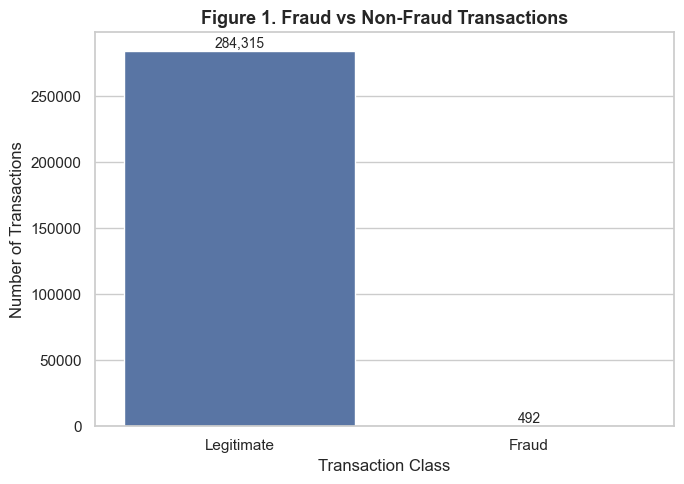

In [6]:
# ============================================================
# Figure 1 - Fraud vs Non-Fraud
# ============================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_full, x="Class_Label", order=["Legitimate", "Fraud"])
plt.title("Figure 1. Fraud vs Non-Fraud Transactions", fontsize=13, weight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "fig1_fraud_vs_nonfraud_improved.png"), dpi=600)
plt.show()

In Figure 1, we can see that the dataset is heavily imbalanced, with the vast majority of transactions being non-fraudulent (284,315) and only a small fraction, about 0.173% (492), labeled as fraud.

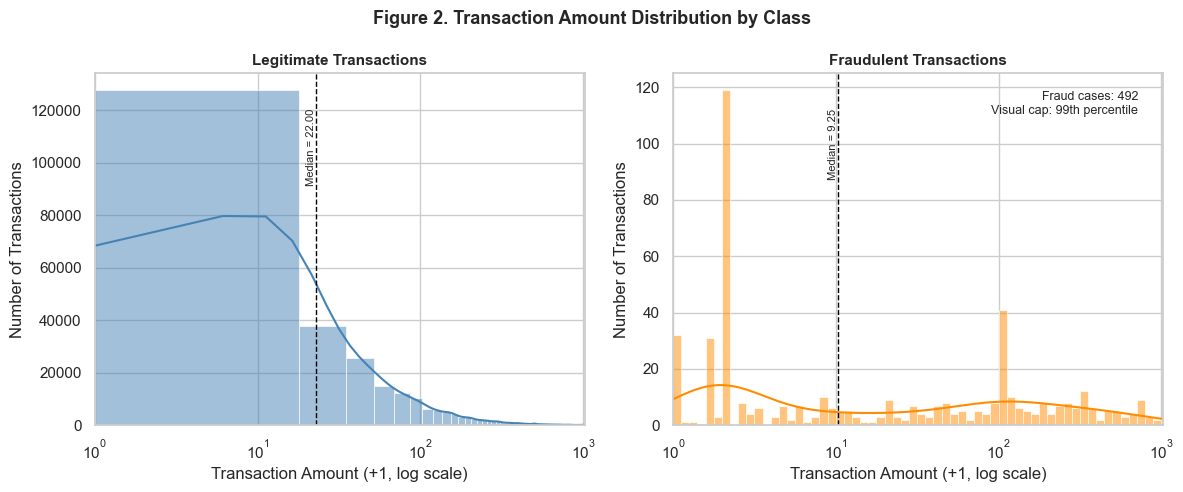

In [7]:
# ============================================================
# Figure 2 - Transaction Amount Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

xmax_cap = df_full["Amount"].quantile(0.99)

legit_amount = df_full.loc[df_full["Class"] == 0, "Amount"]
legit_amount_plot = legit_amount[legit_amount <= xmax_cap]

sns.histplot(
    legit_amount_plot + 1,
    bins=60,
    stat="count",
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Legitimate Transactions", fontsize=11, weight="bold")
axes[0].set_xlabel("Transaction Amount (+1, log scale)")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xscale("log")

legit_median = legit_amount.median() + 1
axes[0].axvline(legit_median, color="black", linestyle="--", linewidth=1)
axes[0].text(
    legit_median,
    axes[0].get_ylim()[1] * 0.9,
    f"Median = {legit_amount.median():.2f}",
    rotation=90,
    va="top",
    ha="right",
    fontsize=8
)

fraud_amount = df_full.loc[df_full["Class"] == 1, "Amount"]
fraud_amount_plot = fraud_amount[fraud_amount <= xmax_cap]

sns.histplot(
    fraud_amount_plot + 1,
    bins=60,
    stat="count",
    kde=True,
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title("Fraudulent Transactions", fontsize=11, weight="bold")
axes[1].set_xlabel("Transaction Amount (+1, log scale)")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xscale("log")

fraud_median = fraud_amount.median() + 1
axes[1].axvline(fraud_median, color="black", linestyle="--", linewidth=1)
axes[1].text(
    fraud_median,
    axes[1].get_ylim()[1] * 0.9,
    f"Median = {fraud_amount.median():.2f}",
    rotation=90,
    va="top",
    ha="right",
    fontsize=8
)

xmin = 1
xmax = xmax_cap + 1
axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)

axes[1].text(
    0.95, 0.95,
    f"Fraud cases: {df_full['Class'].sum()}\nVisual cap: 99th percentile",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    fontsize=9
)

plt.suptitle(
    "Figure 2. Transaction Amount Distribution by Class",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "fig2_trans_amt_by_class.png"),
    dpi=600
)

plt.show()

Figure 2 (left - blue) has a strong right-skewed distribution where large transactions are rare. It shows how legitimate transactions are highly concentrated at lower amounts, with a median value of about 22. Fraudulent transactions (right - orange) have a lower median amount (about 9), but their distribution is more spread out, indicating fraud can occur across a wider range of transaction values. Overall, the plot suggests transaction amount alone is not sufficient to separate fraud from legitimate activity, although fraud tends to occur slightly more often at lower transaction values. Fraud detection is harder because fraud doesn’t only happen at high amounts.

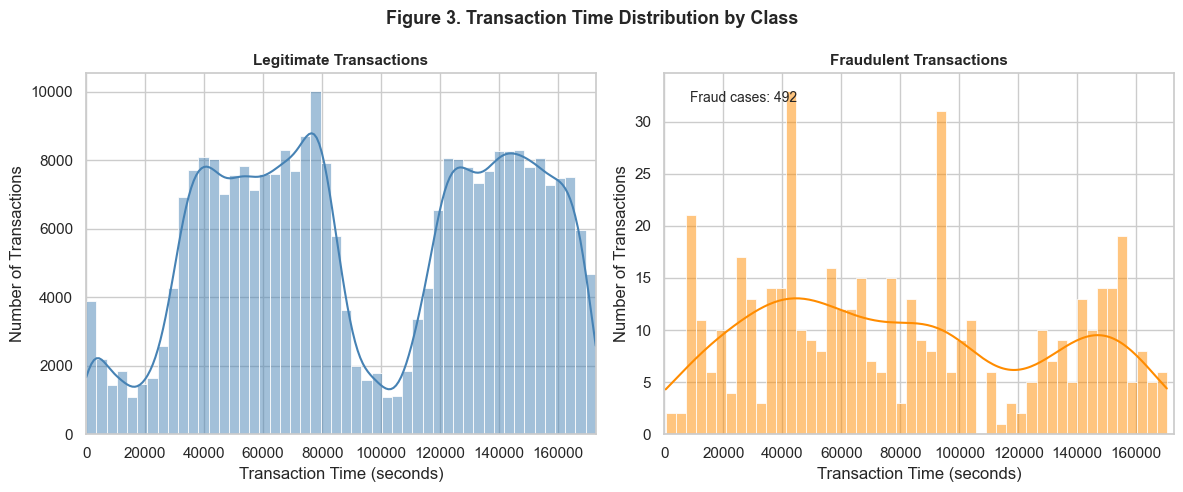

In [8]:
# ============================================================
# Figure 3 - Transaction Time Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

sns.histplot(
    df_full[df_full["Class"] == 0]["Time"],
    bins=50,
    stat="count",
    color="steelblue",
    ax=axes[0],
    kde=True
)

axes[0].set_title("Legitimate Transactions", fontsize=11, weight="bold")
axes[0].set_xlabel("Transaction Time (seconds)")
axes[0].set_ylabel("Number of Transactions")

sns.histplot(
    df_full[df_full["Class"] == 1]["Time"],
    bins=50,
    stat="count",
    color="darkorange",
    ax=axes[1],
    kde=True
)

axes[1].set_title("Fraudulent Transactions", fontsize=11, weight="bold")
axes[1].set_xlabel("Transaction Time (seconds)")
axes[1].set_ylabel("Number of Transactions")
axes[1].text(
    0.05, 0.95,
    f"Fraud cases: {df_full['Class'].sum()}",
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment='top'
)

xmin = df_full["Time"].min()
xmax = df_full["Time"].max()

axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)

plt.suptitle(
    "Figure 3. Transaction Time Distribution by Class",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "fig3_trans_time_side_by_side.png"),
    dpi=600
)

plt.show()

Figure 3 (left - blue) shows that legitimate transactions follow a clear temporal pattern, with peaks that may reflect normal daily transaction activity cycles. Fraudulent transactions appear more scattered over time, without a strong concentration in specific periods, although they generally follow the same overall time range as legitimate transactions. This suggests that transaction time alone may not strongly differentiate fraud, but it could still contribute useful patterns when combined with other features.

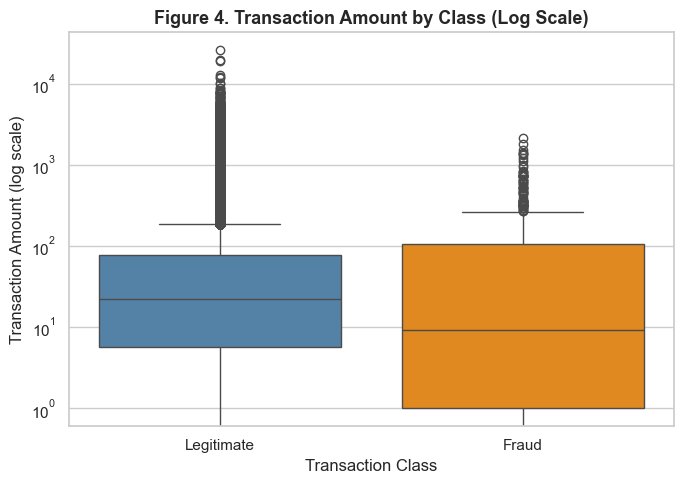

In [9]:
# ============================================================
# Figure 4 - Transaction Amount by Class
# ============================================================
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_full,
    x="Class_Label",
    y="Amount",
    order=["Legitimate", "Fraud"],
    palette={
        "Legitimate": "steelblue",
        "Fraud": "darkorange"
    }
)

plt.yscale("log")

plt.title(
    "Figure 4. Transaction Amount by Class (Log Scale)",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount (log scale)")

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "fig4_trans_amt_by_class_log.png"),
    dpi=600
)

plt.show()


This boxplot shows that legitimate transactions generally have a higher median transaction amount than fraudulent transactions, although both classes contain many outliers at higher values. Fraudulent transactions tend to cluster more at lower amounts but show a wide variability, indicating fraud can occur across different transaction sizes. The log scale highlights that both classes are highly skewed, with most transactions being relatively small and a few very large transactions present in both groups.

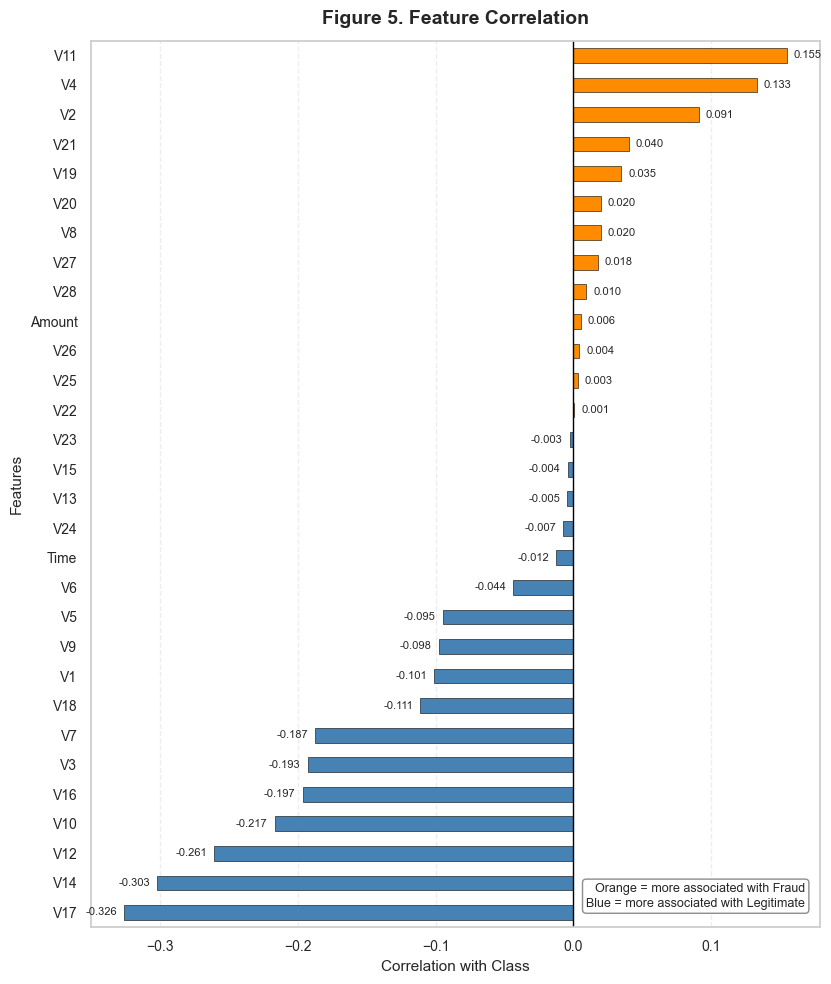

In [10]:
# ============================================================
# Figure 5 - Correlation with Target Class
# ============================================================

corr_with_class = (
    df_full.drop(columns=["Class_Label"])
      .corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values()
)

colors = ["darkorange" if val > 0 else "steelblue" for val in corr_with_class]

plt.figure(figsize=(8.5, 10))

ax = corr_with_class.plot(
    kind="barh",
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

plt.title(
    "Figure 5. Feature Correlation",
    fontsize=14,
    weight="bold",
    pad=12
)

plt.xlabel("Correlation with Class", fontsize=11)
plt.ylabel("Features", fontsize=11)

plt.axvline(0, color="black", linewidth=1)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.grid(axis="y", visible=False)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for i, v in enumerate(corr_with_class):
    ax.text(
        v + (0.005 if v > 0 else -0.005),
        i,
        f"{v:.3f}",
        va="center",
        ha="left" if v > 0 else "right",
        fontsize=8
    )

plt.text(
    0.98, 0.02,
    "Orange = more associated with Fraud\nBlue = more associated with Legitimate",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="grey", alpha=0.9)
)

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "fig5_corr_with_class.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()


This plot shows the Pearson correlation between each feature and the target variable (Class), where +1 indicates a strong positive linear relationship, 0 indicates no linear relationship, and −1 indicates a strong negative linear relationship. Since Class is binary (0 = legitimate - BLUE- , 1 = fraud - ORANGE-), features with positive correlations tend to have higher values in fraudulent transactions, while features with negative correlations tend to have higher values in legitimate transactions (or lower values in fraud cases). Features further from zero show stronger linear associations, while features close to zero have weak relationships with fraud.

From the plot, features such as V11, V4, and V2 show the strongest positive associations with fraud, meaning their higher values tend to appear more frequently in fraudulent transactions. In contrast, features such as V17, V14, and V12 show the strongest negative associations, suggesting these variables are more characteristic of legitimate transactions. However, most correlations are relatively small, indicating that fraud detection likely depends on patterns across multiple variables rather than one single dominant feature.

An important limitation of this analysis is that correlation does not imply causation, and it does not necessarily mean these features are the most important predictors in the final machine learning models. This analysis only measures simple one-variable linear relationships with the target and does not capture complex interactions between variables. Therefore, this plot is useful for initial feature screening and understanding the data structure, but model-based feature importance should be used to determine the true predictive contribution of each variable.


t-SNE input shape: (5492, 32)
Fraud cases in t-SNE sample: 492
Legitimate cases in t-SNE sample: 5000


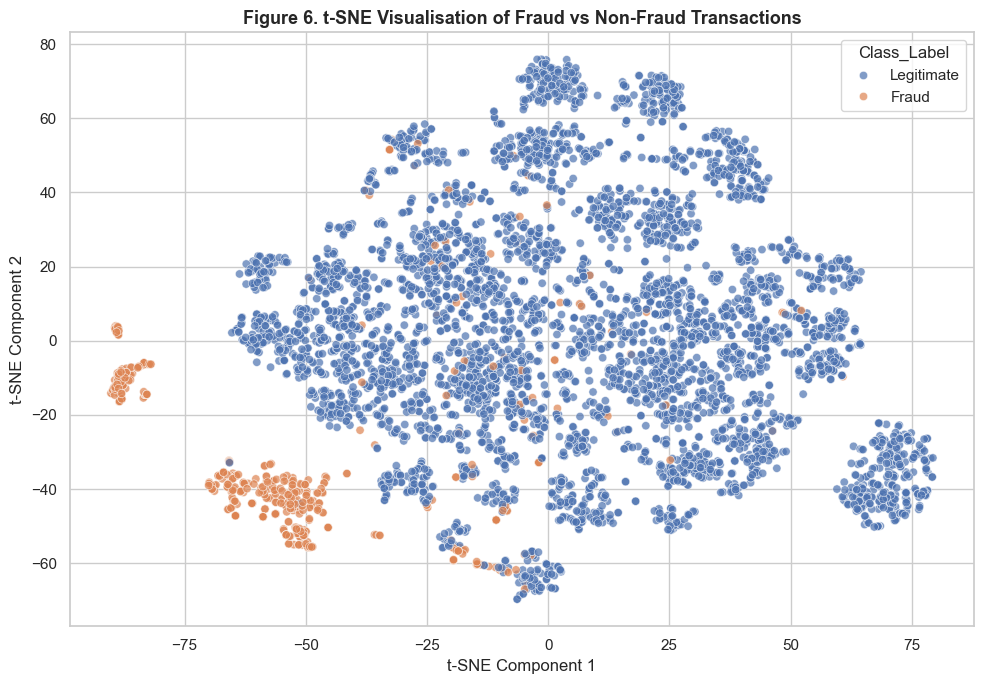

In [11]:
# ============================================================
# Figure 6 - t-SNE VISUALISATION OF FRAUD VS NON-FRAUD
# ============================================================

tsne_source_df = df_full.copy()

if "Class_Label" not in tsne_source_df.columns:
    tsne_source_df["Class_Label"] = tsne_source_df["Class"].map({
        0: "Legitimate",
        1: "Fraud"
    })

fraud_df = tsne_source_df[tsne_source_df["Class"] == 1].copy()
non_fraud_df = tsne_source_df[tsne_source_df["Class"] == 0].copy()

non_fraud_sample_n = min(5000, len(non_fraud_df))
non_fraud_sample = non_fraud_df.sample(
    n=non_fraud_sample_n,
    random_state=RANDOM_STATE
)

tsne_df = pd.concat([fraud_df, non_fraud_sample], axis=0)
tsne_df = tsne_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nt-SNE input shape:", tsne_df.shape)
print("Fraud cases in t-SNE sample:", (tsne_df["Class"] == 1).sum())
print("Legitimate cases in t-SNE sample:", (tsne_df["Class"] == 0).sum())

exclude_cols = ["Class", "Class_Label"]
feature_cols = [col for col in tsne_df.columns if col not in exclude_cols]

X_tsne = tsne_df[feature_cols]
y_tsne = tsne_df["Class"]
label_tsne = tsne_df["Class_Label"]

scaler_tsne = StandardScaler()
X_tsne_scaled = scaler_tsne.fit_transform(X_tsne)

tsne_model = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)

X_tsne_2d = tsne_model.fit_transform(X_tsne_scaled)

tsne_plot_df = pd.DataFrame({
    "TSNE_1": X_tsne_2d[:, 0],
    "TSNE_2": X_tsne_2d[:, 1],
    "Class": y_tsne.values,
    "Class_Label": label_tsne.values
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=tsne_plot_df,
    x="TSNE_1",
    y="TSNE_2",
    hue="Class_Label",
    hue_order=["Legitimate", "Fraud"],
    alpha=0.7
)

plt.title(
    "Figure 6. t-SNE Visualisation of Fraud vs Non-Fraud Transactions",
    fontsize=13,
    weight="bold"
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "fig6_tsne_fraud_visualisation.png"),
    dpi=300
)

plt.show()


This plot shows a t-SNE (t-distributed Stochastic Neighbor Embedding) projection of the transaction data, where each point represents a transaction positioned based on similarity across all features. Transactions that appear close together have similar characteristics, while those farther apart are more different. Because t-SNE reduces many dimensions into two components, the axes themselves do not have a direct physical meaning but instead represent the relative structure of the data.

From the plot, fraudulent transactions (orange) tend to form small clusters that are partially separated from the larger groups of legitimate transactions (blue), suggesting that fraud cases share similar feature patterns that differentiate them from normal behaviour. However, some fraud points appear mixed within legitimate clusters, indicating that not all fraud cases are easily separable and reinforcing the need for machine learning models to detect subtle patterns across multiple variables.

It is important to note that the original dataset was already transformed using PCA for confidentiality reasons, meaning the variables (V1–V28) are principal components rather than raw transaction features. This does not negatively affect the use of t-SNE because both PCA and t-SNE are dimensionality reduction techniques, but they serve different purposes: PCA preserves global variance through linear transformations, while t-SNE focuses on preserving local similarity patterns through non-linear relationships. Therefore, applying t-SNE on PCA-transformed data is still valid for visualising structure and clustering behaviour, although the interpretation focuses on pattern separation rather than real-world feature meaning.

An important limitation of this visualisation is that t-SNE is an unsupervised dimensionality reduction technique used mainly for pattern exploration rather than prediction. The distances between clusters are not strictly quantitative, and the method does not indicate feature importance or causation. Therefore, this plot is useful for visually assessing whether natural grouping exists between fraud and legitimate transactions, but model performance metrics are required to properly evaluate classification effectiveness.

## **Data Preprocessing**
---
To help us solve our classification problem for fraudulent vs non-fraudulent transactions, we selected 4 models:

- Support Vector Machine (SVM)
- Random Forest (RF)
- K-Nearest Neighbors (kNN)
- Linear Discriminant Analysis (LDA).

Due to class imbalance and computational constraints, we used all minority class samples and a **subset** (Dataset B) of majority class samples to ensure efficient training while preserving critical fraud patterns.

In [12]:
# ============================================================
# 5. SAMPLE DATA FOR FASTER RUNTIME
# ============================================================

# Dataset B = 200,000-row modelling subset sampled from full data. 
# This subset is used only for train/test split, SMOTE, scaling and hyperparameter tuning.

X_full = df_full.drop(columns=["Class", "Class_Label"], errors="ignore")
y_full = df_full["Class"]

X_model, _, y_model, _ = train_test_split(
    X_full,
    y_full,
    train_size=MODEL_SAMPLE_SIZE,
    stratify=y_full,
    random_state=RANDOM_STATE
)

df_model = X_model.copy()
df_model["Class"] = y_model.values

print("\nDataset B (Modelling subset) shape:", df_model.shape)

print("\nDataset B class distribution:")
print(df_model["Class"].value_counts())

print("\nDataset B class percentages:")
print(df_model["Class"].value_counts(normalize=True) * 100)


Dataset B (Modelling subset) shape: (200000, 31)

Dataset B class distribution:
Class
0    199655
1       345
Name: count, dtype: int64

Dataset B class percentages:
Class
0    99.8275
1     0.1725
Name: proportion, dtype: float64


The dataset will be separated into the feature matrix (X) and the target variable (y) to support supervised learning and prevent data leakage. 

Dataset B will then be split into training and testing subsets using a stratified 70:30 approach to maintain the class imbalance. 

Visualisations will be used to validate that the class distribution remains consistent, ensuring both subsets are representative and suitable for reliable model training and evaluation.

In [13]:
# ============================================================
# 6. DEFINE FEATURES AND TARGET
# ============================================================

X = df_model.drop("Class", axis=1)
y = df_model["Class"]

In [14]:
# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

In [15]:
# ============================================================
# VISUAL VALIDATION OF TRAIN / TEST SPLIT
# ============================================================

split_summary = pd.DataFrame([
    {
        "Dataset": "Dataset B\n(Model)",
        "Legitimate": int((y == 0).sum()),
        "Fraud": int((y == 1).sum())
    },
    {
        "Dataset": "Training\n(70%)",
        "Legitimate": int((y_train == 0).sum()),
        "Fraud": int((y_train == 1).sum())
    },
    {
        "Dataset": "Testing\n(30%)",
        "Legitimate": int((y_test == 0).sum()),
        "Fraud": int((y_test == 1).sum())
    }
])

fraud_pct = [
    y.mean() * 100,
    y_train.mean() * 100,
    y_test.mean() * 100
]

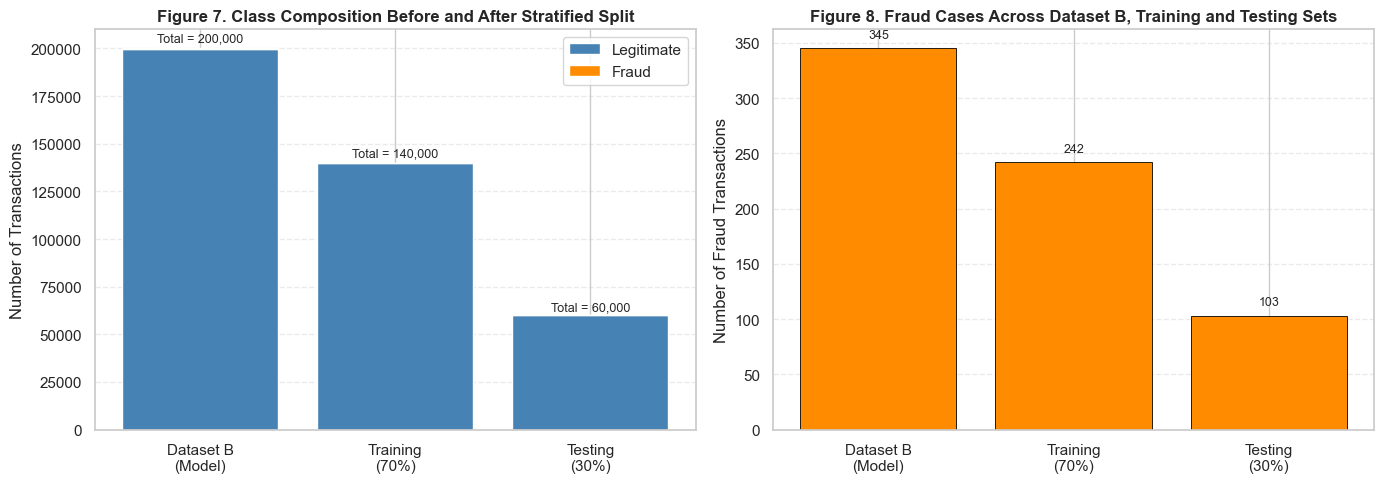

In [16]:
# ============================================================
# Figure 7 and Figure 8
# ============================================================

# Define filenames (same structure as other figures)
fig7_filename = os.path.join(
    PLOTS_DIR,
    f"fig7_train_test_class_distribution_modeled_on_{MODEL_SAMPLE_SIZE}.png"
)

fig8_filename = os.path.join(
    PLOTS_DIR,
    f"fig8_fraud_distribution_modeled_on_{MODEL_SAMPLE_SIZE}.png"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Figure 7: Stacked bar plot for total class composition
# ------------------------------------------------------------
axes[0].bar(
    split_summary["Dataset"],
    split_summary["Legitimate"],
    label="Legitimate",
    color="steelblue"
)

axes[0].bar(
    split_summary["Dataset"],
    split_summary["Fraud"],
    bottom=split_summary["Legitimate"],
    label="Fraud",
    color="darkorange"
)

axes[0].set_title(
    "Figure 7. Class Composition Before and After Stratified Split",
    fontsize=12,
    weight="bold"
)
axes[0].set_ylabel("Number of Transactions")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].legend()

for i, row in split_summary.iterrows():
    total = row["Legitimate"] + row["Fraud"]

    axes[0].text(
        i,
        total + total * 0.01,
        f"Total = {total:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# Figure 8: Fraud-only bar plot
# ------------------------------------------------------------
axes[1].bar(
    split_summary["Dataset"],
    split_summary["Fraud"],
    color="darkorange",
    edgecolor="black",
    linewidth=0.6
)

axes[1].set_title(
    "Figure 8. Fraud Cases Across Dataset B, Training and Testing Sets",
    fontsize=12,
    weight="bold"
)
axes[1].set_ylabel("Number of Fraud Transactions")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for i, fraud_count in enumerate(split_summary["Fraud"]):
    axes[1].text(
        i,
        fraud_count + max(split_summary["Fraud"]) * 0.02,
        f"{fraud_count:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# Save both figures together (same style as your other stages)
plt.savefig(
    os.path.join(
        PLOTS_DIR,
        f"fig7_8_train_test_split_validation_modeled_on_{MODEL_SAMPLE_SIZE}.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()


In [17]:
# ============================================================
# SUMMARY TABLE
# ============================================================

split_table = pd.DataFrame([
    {
        "Subset": "Dataset B (Model)",
        "Rows": len(y),
        "Legitimate": int((y == 0).sum()),
        "Fraud": int((y == 1).sum()),
        "Fraud_%": y.mean() * 100
    },
    {
        "Subset": "Training (70%)",
        "Rows": len(y_train),
        "Legitimate": int((y_train == 0).sum()),
        "Fraud": int((y_train == 1).sum()),
        "Fraud_%": y_train.mean() * 100
    },
    {
        "Subset": "Testing (30%)",
        "Rows": len(y_test),
        "Legitimate": int((y_test == 0).sum()),
        "Fraud": int((y_test == 1).sum()),
        "Fraud_%": y_test.mean() * 100
    }
])

print("\nTrain/Test split summary:")
print(split_table.round(4))


Train/Test split summary:
              Subset    Rows  Legitimate  Fraud  Fraud_%
0  Dataset B (Model)  200000      199655    345   0.1725
1     Training (70%)  140000      139758    242   0.1729
2      Testing (30%)   60000       59897    103   0.1717


The train/test split summary confirms that the stratified sampling was successfully applied, as the fraud percentage remains consistent across Dataset B (0.1725%), the training set (0.1729%), and the testing set (0.1717%). This indicates that the class imbalance was properly preserved during the split, ensuring that both subsets remain representative of the original modelling dataset. Maintaining this distribution is important to ensure reliable model training and an unbiased evaluation of performance.

Due to the severe class imbalance, machine learning models may bias predictions toward the majority class (legitimate transactions), resulting in misleadingly high accuracy but poor fraud detection performance. To mitigate this issue, SMOTE (Synthetic Minority Over-sampling Technique) will be applied to the training dataset to generate synthetic minority samples and improve class balance. This allows the models to better learn fraud patterns while maintaining an unbiased evaluation using the untouched test dataset.

In [18]:
# ============================================================
# 8. APPLY SMOTE TO TRAINING DATA ONLY
# ============================================================
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


After SMOTE:
Class
0    139758
1    139758
Name: count, dtype: int64


In [19]:
# ============================================================
# 9. SCALE DATA FOR SVM, kNN, AND LDA
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

Feature scaling was performed to standardise the predictor variables and prevent features with larger numerical ranges from disproportionately influencing model performance, particularly for SVM, kNN, and LDA. The **StandardScaler** was fitted on the training data after SMOTE was applied and then used to transform the test data using the same parameters. This ensures consistency in data preprocessing while preventing data leakage and preserving the validity of model evaluation.

### Implementation of ML Models
---
After preparing the training data through SMOTE balancing and feature scaling, **hyperparameter tuning** will be performed to optimise the performance of each machine learning model. 

Instead of relying on default parameters, GridSearchCV was used to systematically evaluate different parameter combinations using cross-validation. This approach helps identify the most suitable model configurations while reducing the risk of overfitting and improving generalisation performance. Hyperparameter tuning will be conducted on Dataset B (the modelling subset) to reduce computational cost while still providing reliable parameter selection.

In [20]:
# ============================================================
# 10. HYPERPARAMETER TUNING
# ============================================================

rf_file = os.path.join(SAVED_MODELS_DIR, f"rf_bestparams_{MODEL_SAMPLE_SIZE}.pkl")
if os.path.exists(rf_file):
    rf_best_params = joblib.load(rf_file)
    print(f"Loaded saved RF model best parameters (Sample Size: {MODEL_SAMPLE_SIZE}):", rf_best_params)
else:
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        param_grid={
            "n_estimators": [100, 150],
            "max_depth": [10, 15],
            "min_samples_split": [2, 5]
        },
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    rf_grid.fit(X_train_smote, y_train_smote)
    rf_best_params = rf_grid.best_params_
    joblib.dump(rf_best_params, rf_file)
    print(f"Best RF Parameters (Sample Size: {MODEL_SAMPLE_SIZE}):", rf_best_params)
    print("Random Forest model saved.")

svm_file = os.path.join(SAVED_MODELS_DIR, f"svm_bestparams_{MODEL_SAMPLE_SIZE}.pkl")
if os.path.exists(svm_file):
    svm_best_params = joblib.load(svm_file)
    print(f"Loaded saved SVM model best parameters (Sample Size: {MODEL_SAMPLE_SIZE}):", svm_best_params)
else:
    svm_grid = GridSearchCV(
        SVC(probability=True, class_weight="balanced"),
        param_grid={
            "C": [0.5, 1, 2],
            "gamma": ["scale", 0.1],
            "kernel": ["rbf"]
        },
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    svm_grid.fit(X_train_scaled, y_train_smote)
    svm_best_params = svm_grid.best_params_
    joblib.dump(svm_best_params, svm_file)
    print(f"Best SVM Parameters: (Sample Size: {MODEL_SAMPLE_SIZE})", svm_best_params)
    print("SVM model saved.")

knn_file = os.path.join(SAVED_MODELS_DIR, f"knn_bestparams_{MODEL_SAMPLE_SIZE}.pkl")
if os.path.exists(knn_file):
    knn_best_params = joblib.load(knn_file)
    print(f"Loaded saved kNN model best parameters (Sample Size: {MODEL_SAMPLE_SIZE}):", knn_best_params)
else:
    knn_grid = GridSearchCV(
        KNeighborsClassifier(),
        param_grid={
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        },
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    knn_grid.fit(X_train_scaled, y_train_smote)
    knn_best_params = knn_grid.best_params_
    joblib.dump(knn_best_params, knn_file)
    print(f"Best kNN Parameters (Sample Size: {MODEL_SAMPLE_SIZE}):", knn_best_params)
    print("kNN model saved.")

lda_file = os.path.join(SAVED_MODELS_DIR, f"lda_bestparams_{MODEL_SAMPLE_SIZE}.pkl")
if os.path.exists(lda_file):
    lda_best_params = joblib.load(lda_file)
    print(f"Loaded saved LDA model best parameters (Sample Size: {MODEL_SAMPLE_SIZE}):", lda_best_params)
else:
    lda_grid = GridSearchCV(
        LDA(solver="lsqr"),
        param_grid={
            "shrinkage": [None, 0.1, 0.5, 0.9]
        },
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    lda_grid.fit(X_train_scaled, y_train_smote)
    lda_best_params = lda_grid.best_params_
    joblib.dump(lda_best_params, lda_file)
    print(f"Best LDA Parameters (Sample Size: {MODEL_SAMPLE_SIZE}):", lda_best_params)
    print("LDA model saved.")


Loaded saved RF model best parameters (Sample Size: 200000): {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Loaded saved SVM model best parameters (Sample Size: 200000): {'C': 2, 'gamma': 0.1, 'kernel': 'rbf'}
Loaded saved kNN model best parameters (Sample Size: 200000): {'n_neighbors': 7, 'weights': 'distance'}
Loaded saved LDA model best parameters (Sample Size: 200000): {'shrinkage': 0.5}


After identifying the optimal hyperparameters, these configurations were extracted and applied to the full dataset (Dataset C) to train the final models. This approach ensures that model selection is performed efficiently on a smaller subset while final model training benefits from the complete dataset. The full dataset was then split again into training and testing sets to maintain consistency in the evaluation methodology, followed by the application of SMOTE to the training data to address class imbalance and feature scaling where required.

The final models were trained using the best parameters identified during the tuning phase without repeating GridSearchCV, avoiding unnecessary computational cost. This two-stage approach (hyperparameter tuning on Dataset B followed by final training on Dataset C) follows best practices in machine learning by balancing computational efficiency with robust model development. Saving the trained models also improves reproducibility and enables future reuse without the need for retraining.

Overall, this workflow ensures that the models are properly optimised, trained using the most complete information available, and evaluated on unseen data, supporting reliable performance assessment and potential deployment readiness.

In [21]:
# ============================================================
# 11. EXTRACT BEST PARAMS
# ============================================================
rf_params = rf_best_params
svm_params = svm_best_params
knn_params = knn_best_params
lda_params = lda_best_params

# ============================================================
# 12. FINAL DATASET (FULL DATA)
# ============================================================

# CHANGE: Dataset C = full dataset for final training/evaluation.
# WHY: best parameters are learned on Dataset B, then final models are fitted/evaluated on full data.

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.30,
    stratify=y_full,
    random_state=RANDOM_STATE
)

# ============================================================
# 13. SMOTE ON FULL TRAINING
# ============================================================
smote_full = SMOTE(random_state=RANDOM_STATE)
X_train_full_smote, y_train_full_smote = smote_full.fit_resample(
    X_train_full, y_train_full
)

# ============================================================
# 14. SCALING (FOR SVM, kNN, LDA ONLY)
# ============================================================
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full_smote)
X_test_full_scaled = scaler_full.transform(X_test_full)

# ============================================================
# 15. TRAIN & SAVE FINAL MODELS (NO GRIDSEARCH)
# ============================================================

svm_file = os.path.join(FINAL_MODELS_DIR, f"fullDataset_svm_modeled_on_{MODEL_SAMPLE_SIZE}.pkl")
rf_file = os.path.join(FINAL_MODELS_DIR, f"fullDataset_rf_modeled_on_{MODEL_SAMPLE_SIZE}.pkl")
knn_file = os.path.join(FINAL_MODELS_DIR, f"fullDataset_knn_modeled_on_{MODEL_SAMPLE_SIZE}.pkl")
lda_file = os.path.join(FINAL_MODELS_DIR, f"fullDataset_lda_modeled_on_{MODEL_SAMPLE_SIZE}.pkl")

if os.path.exists(svm_file):
    svm_final = joblib.load(svm_file)
    print("Loaded existing SVM final model")
else:
    svm_final = SVC(probability=True, **svm_params)
    svm_final.fit(X_train_full_scaled, y_train_full_smote)
    joblib.dump(svm_final, svm_file)
    print("Trained and saved SVM final model")

if os.path.exists(rf_file):
    rf_final = joblib.load(rf_file)
    print("Loaded existing RF final model")
else:
    rf_final = RandomForestClassifier(random_state=RANDOM_STATE, **rf_params)
    rf_final.fit(X_train_full_smote, y_train_full_smote)
    joblib.dump(rf_final, rf_file)
    print("Trained and saved RF final model")

if os.path.exists(knn_file):
    knn_final = joblib.load(knn_file)
    print("Loaded existing kNN final model")
else:
    knn_final = KNeighborsClassifier(**knn_params)
    knn_final.fit(X_train_full_scaled, y_train_full_smote)
    joblib.dump(knn_final, knn_file)
    print("Trained and saved kNN final model")

if os.path.exists(lda_file):
    lda_final = joblib.load(lda_file)
    print("Loaded existing LDA final model")
else:
    lda_final = LDA(solver="lsqr", **lda_params)
    lda_final.fit(X_train_full_scaled, y_train_full_smote)
    joblib.dump(lda_final, lda_file)
    print("Trained and saved LDA final model")

Loaded existing SVM final model
Loaded existing RF final model
Loaded existing kNN final model
Loaded existing LDA final model


A reusable evaluation function will be implemented to ensure a consistent and comparable assessment across all models. 

Multiple performance metrics are calculated, including precision, recall, F1-score and ROC-AUC, as accuracy alone can be misleading in highly imbalanced datasets such as fraud detection. 

Confusion matrices and ROC curves will be also generated to provide visual insight into classification performance and model discrimination capability. 

This structured evaluation framework supports objective model comparison and strengthens the reliability of the results.

In [22]:
# ============================================================
# 16. MODEL EVALUATION FUNCTION
# ============================================================
def evaluate_model(
    name,
    model,
    X_train_data,
    y_train_data,
    X_test_data,
    y_test_data,
    fit_model=True,
    save_plots=True,
    plots_dir=PLOTS_DIR
):
    print(f"\n{'='*70}")
    print(f"RUNNING {name}")
    print(f"{'='*70}")

    if fit_model:
        model.fit(X_train_data, y_train_data)

    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
    else:
        y_prob = model.decision_function(X_test_data)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, zero_division=0)
    recall = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test_data, y_prob)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    report_dict = classification_report(
        y_test_data,
        y_pred,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()
    rename_dict = {
        '0': '0 (Non Fraud)',
        '1': '1 (Fraud)',
    }
    report_df = report_df.rename(index=rename_dict)
    print("\nClassification Report:")
    print(report_df.round(3))

    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_test_data, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"Confusion Matrix - {name}")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    fpr, tpr, _ = roc_curve(y_test_data, y_prob)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_title(f"ROC Curve - {name}")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

    plt.tight_layout()
    if save_plots:
        plt.savefig(
            os.path.join(plots_dir, f"{safe_name}_confusion_and_roc_modeled_on_{MODEL_SAMPLE_SIZE}.png"),
            bbox_inches="tight",
            dpi=600
        )
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    }

#### SVM (Support Vector Machine)

In this project, a Support Vector Machine (SVM) classifier was implemented to determine the optimal hyperplane that maximises the margin between fraudulent and legitimate transactions in the feature space. 

Hyperparameter tuning was performed using GridSearchCV to optimise model performance and improve generalisation. 

VM is particularly suitable for this problem due to its robustness in high-dimensional feature spaces and its ability to model complex decision boundaries, which are common in fraud detection datasets.


RUNNING SVM (Full Dataset)
Accuracy : 0.9985
Precision: 0.5674
Recall   : 0.6824
F1 Score : 0.6196
ROC-AUC  : 0.9504

Classification Report:
               precision  recall  f1-score    support
0 (Non Fraud)      0.999   0.999     0.999  85295.000
1 (Fraud)          0.567   0.682     0.620    148.000
accuracy           0.999   0.999     0.999      0.999
macro avg          0.783   0.841     0.809  85443.000
weighted avg       0.999   0.999     0.999  85443.000


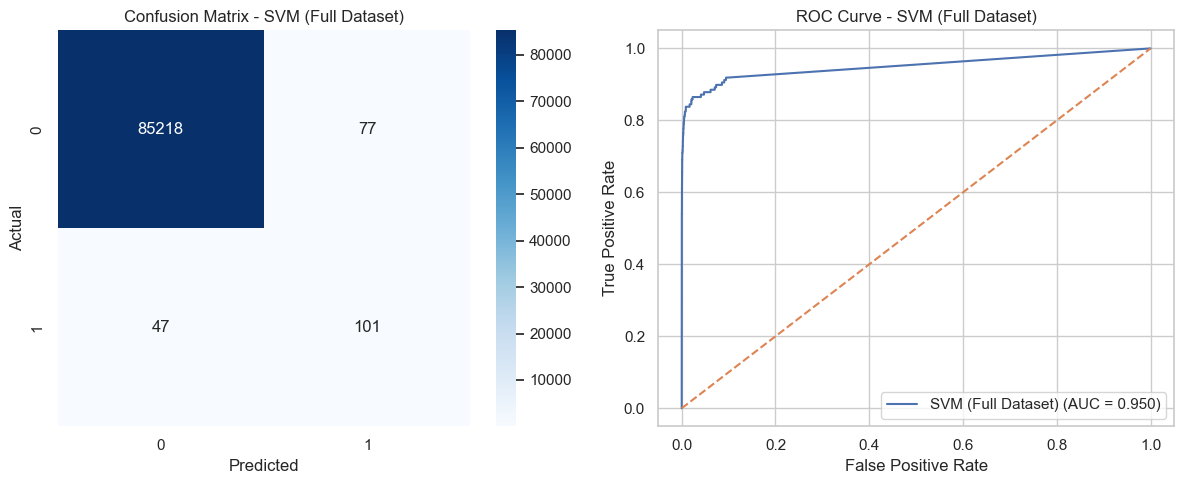

In [23]:
# ============================================================
# 17. EVALUATE SVM (SUPPORT VECTOR MACHINE)
# ============================================================
svm_results = evaluate_model(
    "SVM (Full Dataset)",
    svm_final,
    None, None,
    X_test_full_scaled,
    y_test_full,
    fit_model=False # True if training it for smaller dataset, False when using saved .pkl models
)

The SVM model achieved a very high accuracy of 0.9985, with a precision of 0.5674, recall of 0.6824, F1-score of 0.6196, and ROC-AUC of 0.9504. As expected in highly imbalanced datasets such as fraud detection, accuracy alone is not a reliable indicator of performance. Instead, precision, recall, F1-score and ROC-AUC provide a more meaningful evaluation of the model’s ability to detect fraudulent transactions.

The fraud precision of 56.7% indicates that slightly more than half of the transactions flagged as fraud were actually fraudulent, while the recall of 68.2% shows that the model successfully detected approximately two-thirds of all fraud cases, missing 47 out of 148 fraud transactions. The F1-score of 0.6196 reflects the expected trade-off between detecting fraud and limiting false alarms, which is typical in imbalanced classification problems.

The confusion matrix further highlights this performance. The model correctly detected 101 out of 148 fraud cases, while missing 47 fraud transactions, and generated only 77 false positives among more than 85,000 legitimate transactions, indicating a low false positive rate.

- True Negatives (TN): 85,218 – legitimate transactions correctly classified
- False Positives (FP): 77 – legitimate transactions incorrectly flagged as fraud
- False Negatives (FN): 47 – fraud cases missed
- True Positives (TP): 101 – fraud cases correctly detected

The ROC-AUC score of 0.9504 indicates strong class separability, meaning the model is effective at distinguishing fraudulent from legitimate transactions across different decision thresholds. Overall, the SVM model demonstrates good fraud detection capability with a reasonable balance between recall and precision, although its fraud detection performance is slightly lower than that achieved by the Random Forest model.

#### Random Forest
In this project, the Random Forest classifier was implemented as a key model for detecting fraudulent credit-card transactions. Fraud patterns are typically rare, complex, and often non-linear, particularly within anonymised PCA-transformed features, making a model capable of capturing complex feature interactions essential. Random Forest addresses this by aggregating predictions from multiple decision trees, which helps reduce overfitting while improving model robustness and generalisation performance. Its ability to handle high-dimensional data, tolerate noise, and perform well without strict feature scaling makes it a strong candidate for fraud detection and a valuable benchmark for comparison against other models such as SVM, LDA, and kNN.


RUNNING Random Forest (Full Dataset)
Accuracy : 0.9992
Precision: 0.7643
Recall   : 0.8108
F1 Score : 0.7869
ROC-AUC  : 0.9765

Classification Report:
               precision  recall  f1-score    support
0 (Non Fraud)      1.000   1.000     1.000  85295.000
1 (Fraud)          0.764   0.811     0.787    148.000
accuracy           0.999   0.999     0.999      0.999
macro avg          0.882   0.905     0.893  85443.000
weighted avg       0.999   0.999     0.999  85443.000


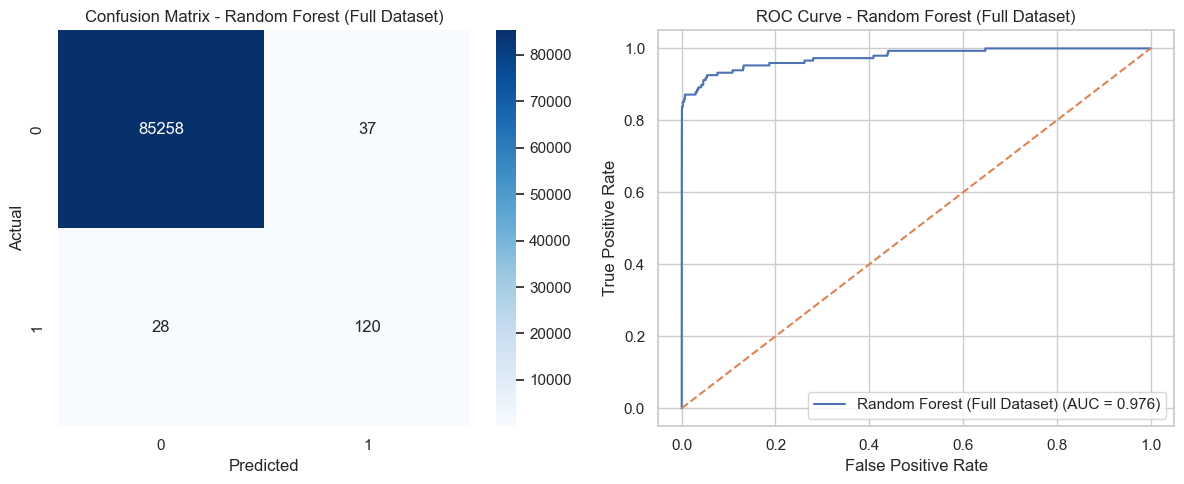

In [24]:
# ============================================================
# 18. EVALUATE RANDOM FOREST
# ============================================================
rf_results = evaluate_model(
    "Random Forest (Full Dataset)",
    rf_final,
    None, None,
    X_test_full,
    y_test_full,
    fit_model=False
)

The tuned Random Forest model demonstrated strong performance across all evaluation metrics, achieving an accuracy of 0.9992, precision of 0.7643, recall of 0.8108, F1-score of 0.7869, and ROC-AUC of 0.9765. While the very high accuracy is expected due to the strong class imbalance, the more meaningful fraud detection metrics—precision, recall and ROC-AUC—confirm that the model performs **very well** in identifying fraudulent transactions.

The model achieved a fraud precision of 76.4%, meaning that most transactions flagged as fraud were correctly identified. The recall of 81.1% indicates that the model successfully detected more than four-fifths of all fraud cases, missing only 28 out of 148 cases. The F1-score of 0.7869 confirms a strong balance between detecting fraud and maintaining prediction reliability, indicating better overall fraud classification performance compared to models with lower precision–recall balance.

The confusion matrix further supports this strong performance. The model correctly identified:

- True Negatives (TN): 85,258 – legitimate transactions correctly classified
- False Positives (FP): 37 – legitimate transactions incorrectly flagged as fraud (out of more than 85000 legitimate transactions)
- False Negatives (FN): 28 – fraud cases missed
- True Positives (TP): 120 – fraud cases correctly detected (out of 148 real fraud transactions)

The ROC-AUC score of 0.9765 indicates excellent class separability, meaning the model is highly effective at distinguishing fraudulent from legitimate transactions across different decision thresholds. Overall, the Random Forest model demonstrates strong robustness to class imbalance and provides an effective balance between fraud detection capability and false positive control, making it one of the strongest performing models in this study.

#### kNN
k-Nearest Neighbors (kNN) classifies each transaction based on the majority class of its nearest neighbors. GridSearchCV is used to tune the number of neighbors and weighting scheme, helping the model better detect fraudulent transactions in the imbalanced credit card dataset.


RUNNING kNN (Full Dataset)
Accuracy : 0.9979
Precision: 0.4366
Recall   : 0.7905
F1 Score : 0.5625
ROC-AUC  : 0.9082

Classification Report:
               precision  recall  f1-score    support
0 (Non Fraud)      1.000   0.998     0.999  85295.000
1 (Fraud)          0.437   0.791     0.562    148.000
accuracy           0.998   0.998     0.998      0.998
macro avg          0.718   0.894     0.781  85443.000
weighted avg       0.999   0.998     0.998  85443.000


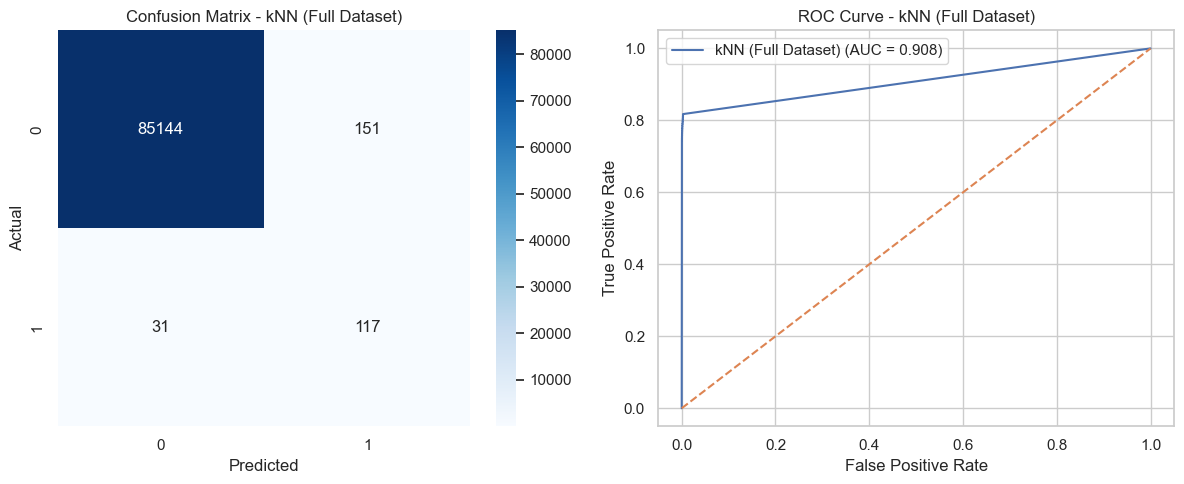

In [25]:
# ============================================================
# 19. EVALUATE kNN
# ============================================================
knn_results = evaluate_model(
    "kNN (Full Dataset)",
    knn_final,
    None, None,
    X_test_full_scaled,
    y_test_full,
    fit_model=False
)

The tuned kNN model achieved an overall accuracy of 0.9979, with a precision of 0.4366, recall of 0.7905, F1-score of 0.5625, and ROC-AUC of 0.9082. As with the other models, the very high accuracy is influenced by the strong class imbalance and therefore is less informative than the fraud-focused metrics. The recall indicates that the model successfully detects about 79% of fraudulent transactions, but the relatively low precision shows that many transactions flagged as fraud are actually legitimate.

The precision of 43.7% means that fewer than half of the transactions predicted as fraud are truly fraudulent, indicating a relatively high number of false alarms compared to the other models. However, the recall of 79.1% demonstrates that the model is still effective at capturing most fraud cases. The F1-score of 0.5625 reflects this trade-off, showing moderate performance but weaker balance between fraud detection and prediction reliability compared to Random Forest and SVM.

The confusion matrix confirms this behaviour. The model correctly detected 117 out of 148 fraud cases, missing 31 fraud transactions, but generated 151 false positives among more than 85,000 legitimate transactions, which explains the lower precision.

- True Negatives (TN): 85,144 – legitimate transactions correctly classified
- False Positives (FP): 151 – legitimate transactions incorrectly flagged as fraud
- False Negatives (FN): 31 – fraud cases missed
- True Positives (TP): 117 – fraud cases correctly detected

The ROC-AUC score of 0.9082 indicates good overall class separation, although lower than both SVM and Random Forest, suggesting that kNN is less effective at distinguishing fraudulent from legitimate transactions across decision thresholds.

Overall, the kNN model demonstrates reasonable fraud detection capability through relatively high recall, but its lower precision and higher false positive rate make it less suitable than Random Forest and SVM for this dataset. While it may be useful in scenarios where detecting as many fraud cases as possible is the priority, the higher number of false alarms could increase investigation costs and operational burden.

#### Linear Discriminant Analysis (LDA)
Linear Discriminant Analysis (LDA) reduces dimensionality while maximizing class separation, which is important for credit card fraud detection where fraudulent transactions are rare. GridSearchCV is used to tune shrinkage, helping LDA better distinguish fraud from legitimate transactions in this highly imbalanced dataset.


RUNNING LDA (Full Dataset)
Accuracy : 0.9975
Precision: 0.3830
Recall   : 0.7297
F1 Score : 0.5023
ROC-AUC  : 0.9647

Classification Report:
               precision  recall  f1-score    support
0 (Non Fraud)      1.000   0.998     0.999  85295.000
1 (Fraud)          0.383   0.730     0.502    148.000
accuracy           0.997   0.997     0.997      0.997
macro avg          0.691   0.864     0.751  85443.000
weighted avg       0.998   0.997     0.998  85443.000


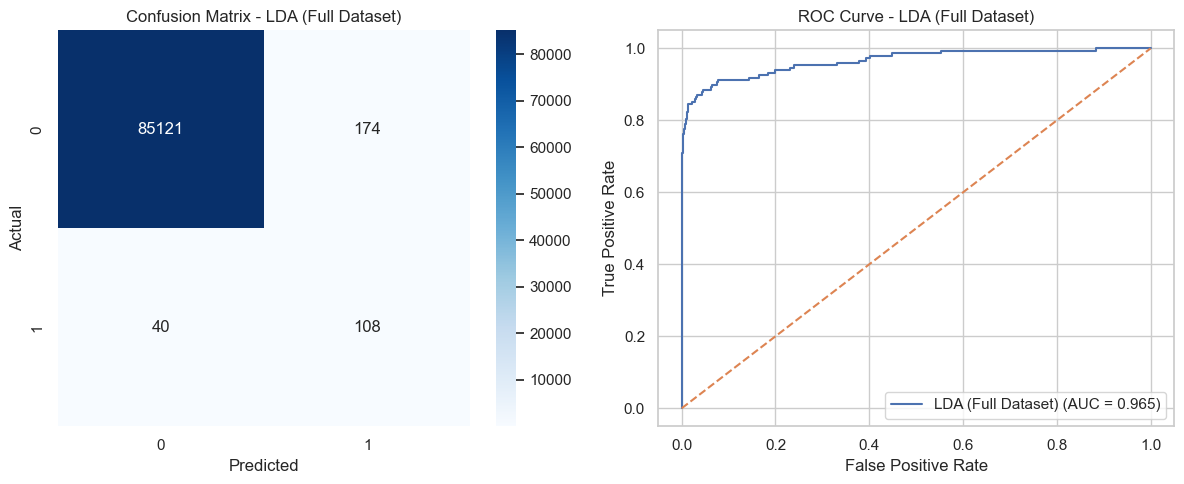

In [26]:
# ============================================================
# 20. EVALUATE LDA
# ============================================================
lda_results = evaluate_model(
    "LDA (Full Dataset)",
    lda_final,
    None, None,
    X_test_full_scaled,
    y_test_full,
    fit_model=False
)

The LDA model achieved an overall accuracy of 0.9975, with a precision of 0.3830, recall of 0.7297, F1-score of 0.5023, and ROC-AUC of 0.9647. As with the other models, the high accuracy is largely influenced by the strong class imbalance and therefore is less informative than the fraud-focused metrics. The ROC-AUC indicates that the model has strong overall ability to distinguish between fraudulent and legitimate transactions despite its lower precision.

The fraud precision of 38.3% indicates that many transactions predicted as fraud are actually legitimate, reflecting a relatively high false positive proportion. However, the recall of 73.0% shows that the model still captures a substantial proportion of fraud cases. The F1-score of 0.5023 reflects this trade-off, indicating moderate performance but weaker balance between fraud detection and prediction reliability compared to SVM and Random Forest.

The confusion matrix further illustrates this behaviour. The model correctly detected 108 out of 148 fraud cases, while missing 40 fraud transactions, and generated 174 false positives among more than 85,000 legitimate transactions, explaining the relatively low precision.

- True Negatives (TN): 85,121 – legitimate transactions correctly classified
- False Positives (FP): 174 – legitimate transactions incorrectly flagged as fraud
- False Negatives (FN): 40 – fraud cases missed
- True Positives (TP): 108 – fraud cases correctly detected

The ROC-AUC score of 0.9647 indicates strong class separability, suggesting that although the model produces more false alarms, it still ranks fraudulent transactions effectively compared to legitimate ones. This behaviour is typical of linear models like LDA, which may struggle to fully capture complex non-linear fraud patterns compared to ensemble methods such as Random Forest.

Overall, the LDA model demonstrates reasonable fraud detection capability but is less effective than Random Forest and SVM due to its lower precision and higher false positive rate. While it provides good class separation, its operational usefulness may be limited by the higher number of false alarms compared to the stronger performing models.

## Discussion & Conclusion
---
This project investigated the application of multiple machine learning classification algorithms for the detection of fraudulent credit card transactions using a structured end-to-end machine learning pipeline. Several models, including Support Vector Machine (SVM), Random Forest, k-Nearest Neighbour (kNN), and Linear Discriminant Analysis (LDA), were implemented and evaluated using performance metrics such as precision, recall, F1-score and ROC-AUC, which are more appropriate than accuracy alone for highly imbalanced datasets.

To ensure an efficient and reproducible modelling workflow, the project followed a three-dataset strategy. Dataset A (full dataset) was used for exploratory data analysis to understand class imbalance and data characteristics. Dataset B (a 200,000-transaction subset) was then used for model development, including train/test splitting, SMOTE application, feature scaling, and hyperparameter tuning using GridSearchCV to reduce computational cost. Finally, Dataset C (the full dataset) was used to train the final models using the optimal parameters identified during tuning and to perform the final evaluation on unseen test data.

This staged modelling approach follows best practices in machine learning by separating exploration, model tuning, and final evaluation. It ensures computational efficiency during experimentation while allowing the final models to benefit from the full dataset. Additionally, the use of stratified sampling preserved the original class distribution, while SMOTE was applied only to the training data to address class imbalance without introducing data leakage. Overall, this workflow supports robust model development, fair evaluation, and reproducible results.

In [27]:
# ============================================================
# 21. FINAL MODEL COMPARISON TABLE
# ============================================================
results = [
    svm_results,
    rf_results,
    knn_results,
    lda_results
]

results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values(by="ROC_AUC", ascending=False)

print("\nSummary of All Models:")
print(results_sorted.to_string(index=False))


Summary of All Models:
                       Model  Accuracy  Precision   Recall  F1_Score  ROC_AUC
Random Forest (Full Dataset)  0.999239   0.764331 0.810811  0.786885 0.976492
          LDA (Full Dataset)  0.997495   0.382979 0.729730  0.502326 0.964708
          SVM (Full Dataset)  0.998549   0.567416 0.682432  0.619632 0.950421
          kNN (Full Dataset)  0.997870   0.436567 0.790541  0.562500 0.908225


#### Model Comparison and Best Performing Model

Based on the comparative evaluation of the four models, Random Forest clearly demonstrates the strongest overall performance for fraud detection. It achieved the best balance between fraud precision (0.764) and recall (0.811), resulting in the highest F1-score (0.787) and the highest ROC-AUC (0.976) among all models. This indicates that Random Forest not only detects a large proportion of fraudulent transactions but also maintains a relatively low number of false alarms compared to the other models.

SVM showed the second strongest performance, with an F1-score of 0.620 and ROC-AUC of 0.950, but with noticeably lower recall and precision compared to Random Forest. While it demonstrates good class separation, it misses more fraud cases and detects fewer true frauds overall. kNN achieved relatively high recall (0.791), meaning it detects many fraud cases, but its low precision (0.437) indicates a large number of false positives, which could increase investigation workload. Similarly, LDA showed good ROC-AUC (0.965) but the lowest fraud precision (0.383) and lowest F1-score (0.502), making it the weakest model in terms of practical fraud detection performance.

Overall, the results indicate that while all models demonstrate good ability to distinguish between classes, Random Forest provides the best balance between fraud detection capability and operational practicality, making it the most suitable model for this problem.

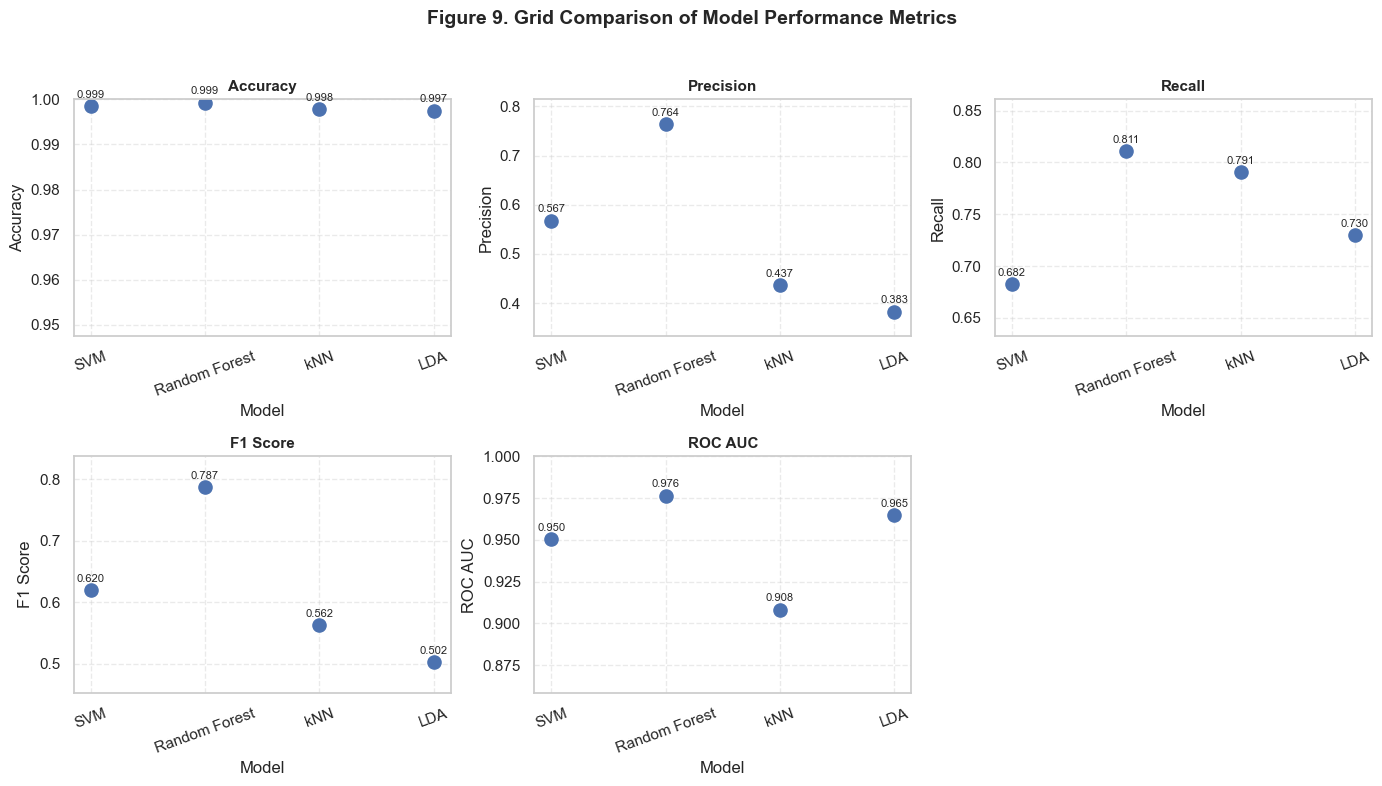

In [28]:
# ============================================================
# 22. COMPARISON OF MODEL PERFORMANCE METRICS
# ============================================================

grid_filename = os.path.join(
    PLOTS_DIR,
    f"fig9_model_metric_grid_modeled_on_{MODEL_SAMPLE_SIZE}.png"
)

# Rebuild results table from evaluated models
results_grid = pd.DataFrame([
    svm_results,
    rf_results,
    knn_results,
    lda_results
])

# Clean model names for display
results_grid["Model"] = results_grid["Model"].str.replace(" (Full Dataset)", "", regex=False)

# Metrics to plot
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

# Create grid
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].scatter(results_grid["Model"], results_grid[metric], s=90)
    axes[i].set_title(metric.replace("_", " "), fontsize=11, weight="bold")
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel(metric.replace("_", " "))
    axes[i].grid(True, linestyle="--", alpha=0.4)
    axes[i].tick_params(axis="x", rotation=20)

    # Set sensible y-axis limits
    ymin = max(0, results_grid[metric].min() - 0.05)
    ymax = min(1.0, results_grid[metric].max() + 0.05)
    axes[i].set_ylim(ymin, ymax)

    # Add values next to points
    for x, y in zip(results_grid["Model"], results_grid[metric]):
        axes[i].annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8
        )

# Remove the unused 6th subplot
fig.delaxes(axes[5])

fig.suptitle(
    "Figure 9. Grid Comparison of Model Performance Metrics",
    fontsize=14,
    weight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(grid_filename, dpi=600, bbox_inches="tight")
plt.show()

#### Most Suitable Metric for Fraud Detection

For fraud detection problems, the most informative metric is typically the F1-score for the fraud class, as it balances both precision and recall. In highly imbalanced datasets, accuracy can be misleading because predicting all transactions as legitimate would still produce very high accuracy. Recall is critical because missing fraud cases represents direct financial risk, while precision is important because excessive false positives increase investigation costs and customer friction.

The F1-score combines these two aspects into a single metric, providing a balanced measure of how effectively the model detects fraud while controlling false alarms. In this study, Random Forest achieved the highest F1-score, confirming it as the most effective model at balancing fraud detection and prediction reliability.

#### Dataset and Model Limitations

One of the main challenges in this project is the extreme class imbalance, where legitimate transactions significantly outnumber fraudulent ones. This imbalance can bias models toward predicting the majority class and may reduce their ability to detect rare fraud patterns. Although SMOTE was applied to address this issue during training, synthetic sampling may not fully capture the complexity of real fraud behaviour.

Additionally, the dataset consists of PCA-transformed features, which improves privacy but limits interpretability since the original feature meaning is unknown. Another limitation is that fraud patterns may change over time (concept drift), meaning models trained on historical data may require periodic retraining to remain effective. Finally, although care was taken to avoid data leakage by applying SMOTE only to training data, model performance may still differ under real production conditions.

#### Recommendations for Future Work

Future improvements could include testing more advanced ensemble models such as Gradient Boosting, XGBoost, or LightGBM, which often perform strongly on tabular fraud datasets. Further improvements could also come from threshold optimisation (instead of default 0.5 classification), cost-sensitive learning, or anomaly detection approaches.

Additional work could also focus on improving feature engineering, implementing cross-validation on the full dataset, and developing monitoring strategies for model performance after deployment. Regular retraining using updated transaction data would also help maintain model effectiveness as fraud patterns evolve.

## References

- Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015). Calibrating probability with undersampling for unbalanced classification. 2015 IEEE Symposium Series on Computational Intelligence, 159–166. https://doi.org/10.1109/SSCI.2015.33
  
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.
  
- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python toolbox to tackle the curse of imbalanced datasets in machine learning. Journal of Machine Learning Research, 18(17), 1–5.
  
- McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 51–56.
  
- Waskom, M. L. (2021). Seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021

## APPENDIX A - Data Workflow and Sampling Strategy Explanation

To ensure a robust and reproducible machine learning workflow, this project followed a structured data management strategy separating exploratory analysis, model development, and final evaluation. 

This workflow is implemented throughout the script (see Stages 2–23) and is visually summarised in Figure A1 and Figure A2, which illustrate how the dataset evolves across the modelling process.

The workflow begins with **Dataset A** (full dataset), loaded during Stage 2 (Load Dataset & Data Quality Checks). This dataset contains the complete set of approximately 284,000 transactions and is used primarily for exploratory data analysis (EDA). The purpose of this stage is to understand the structure of the data, identify missing values or duplicates, and most importantly quantify the class imbalance. As shown in Figure A2, fraudulent transactions represent only about 0.17% of all transactions, highlighting a severe imbalance typical of fraud detection problems.

To enable efficient model experimentation, **Dataset B** (modelling subset) is created in Stage 5 (Create Modelling Dataset) by sampling 200,000 transactions from the full dataset. This subset maintains the same fraud distribution as the original data, which can be verified in Figure A2, where the fraud percentage remains consistent between Dataset A and Dataset B. This approach reduces computational cost during model development while preserving the statistical characteristics of the original dataset.

Dataset B is then divided into training and testing subsets during Stage 7 (Train/Test Split) using a stratified 70:30 split. Stratification ensures that both the training and testing sets maintain the same fraud proportion as the original modelling dataset. This is important because non-stratified splitting could lead to misleading performance evaluation if the minority class becomes unevenly distributed between training and testing datasets. The preservation of class distribution can be observed in the workflow summary and visualised in Figure A2.

Because the dataset is highly imbalanced, SMOTE (Synthetic Minority Oversampling Technique) is applied during Stage 8 (Apply SMOTE to Training Data Only). SMOTE generates synthetic fraud samples based on nearest neighbour relationships in the feature space, increasing the representation of the minority class. As shown in Figure A2, the fraud percentage increases to approximately 50% after SMOTE, confirming that the classes have been balanced. Importantly, this process is applied only to the training data and not the testing data, which follows best practice to prevent data leakage and ensure fair model evaluation.

Feature scaling is then performed in Stage 9 (Feature Scaling) for models sensitive to feature magnitude such as SVM, kNN and LDA. This ensures that all features contribute equally to distance-based and margin-based algorithms, preventing variables with larger numerical ranges from dominating the learning process.

Hyperparameter tuning and model implementation occur in Stages 10–16, where multiple models are trained and evaluated using the modelling subset. This staged modelling approach allows efficient parameter optimisation without incurring the full computational cost of training repeatedly on the complete dataset.

Following model selection, the workflow moves to **Dataset C** (final training dataset) during Stages 17–20, where the full dataset is again used to train the final models using the optimal parameters identified during the tuning phase. This approach ensures that the final models benefit from the full available information while maintaining the methodological rigour of parameter tuning performed on Dataset B.

The workflow summary presented in Stage 23 (Data Flow / Sampling Summary) and visualised in Figure A1 and Figure A2 confirms the expected behaviour of the data pipeline:

- The number of rows decreases during subset selection and train/test splitting, reflecting controlled sampling decisions (Figure A1)
- The number of rows increases after SMOTE due to synthetic sample generation (Figure A1)
- Fraud percentages remain stable during sampling and splitting, confirming correct stratified sampling (Figure A2)
- Fraud percentage increases to approximately 50% after SMOTE, demonstrating successful class balancing (Figure A2)
- The original class imbalance is preserved in the final evaluation datasets, ensuring realistic model testing conditions (Figure A2)

From a machine learning methodology perspective, this staged workflow reflects best practices because it:

- Separates exploration, training, and evaluation phases (Stages 2–23)
- Prevents data leakage through correct SMOTE application (Stage 8)
- Maintains class representativeness through stratified sampling (Stage 7)
- Improves model learning through controlled class balancing (Stage 8)
- Ensures fair model evaluation using unseen test data (Stages 16–20)
- Balances computational efficiency with statistical robustness (Stages 5 and 17)

Overall, this structured workflow demonstrates a systematic and reproducible approach to fraud detection modelling. By clearly separating modelling stages and documenting dataset transformations, the project ensures that performance results are technically valid, reproducible, and suitable for real-world deployment considerations.


Data flow summary:
                                      Stage    Rows  Fraud_Cases  \
0               Dataset A - Full data (EDA)  284807          492   
1              Dataset B - Modelling subset  200000          345   
2                   Dataset B - Train split  140000          242   
3             Dataset B - Train after SMOTE  279516       139758   
4        Dataset C - Final full train split  199364          344   
5  Dataset C - Final full train after SMOTE  398040       199020   

   Fraud_Percent  
0       0.172749  
1       0.172500  
2       0.172857  
3      50.000000  
4       0.172549  
5      50.000000  


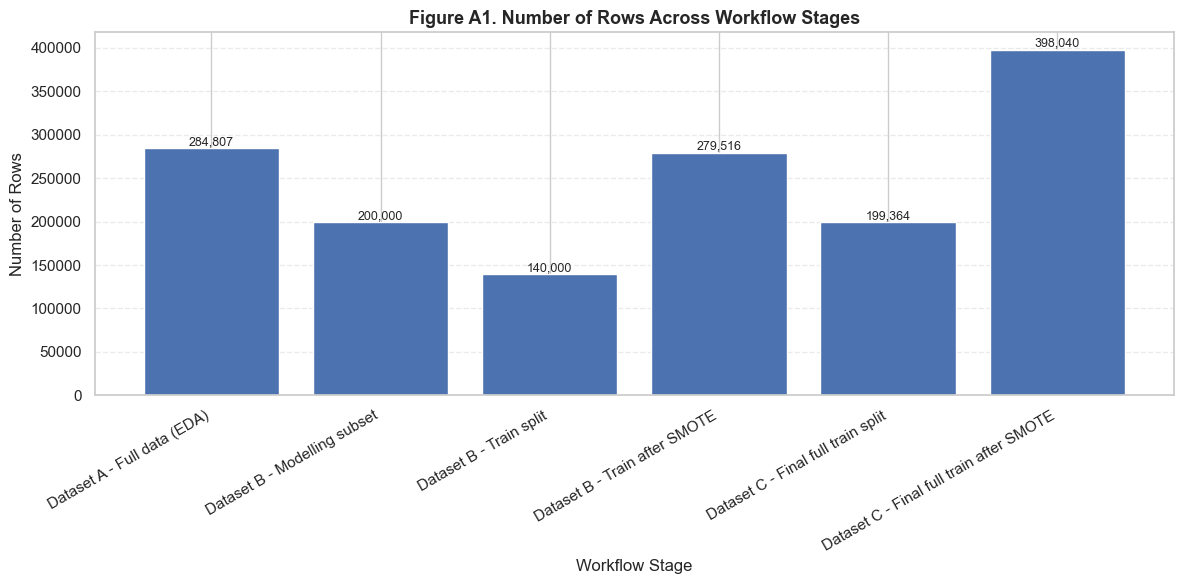

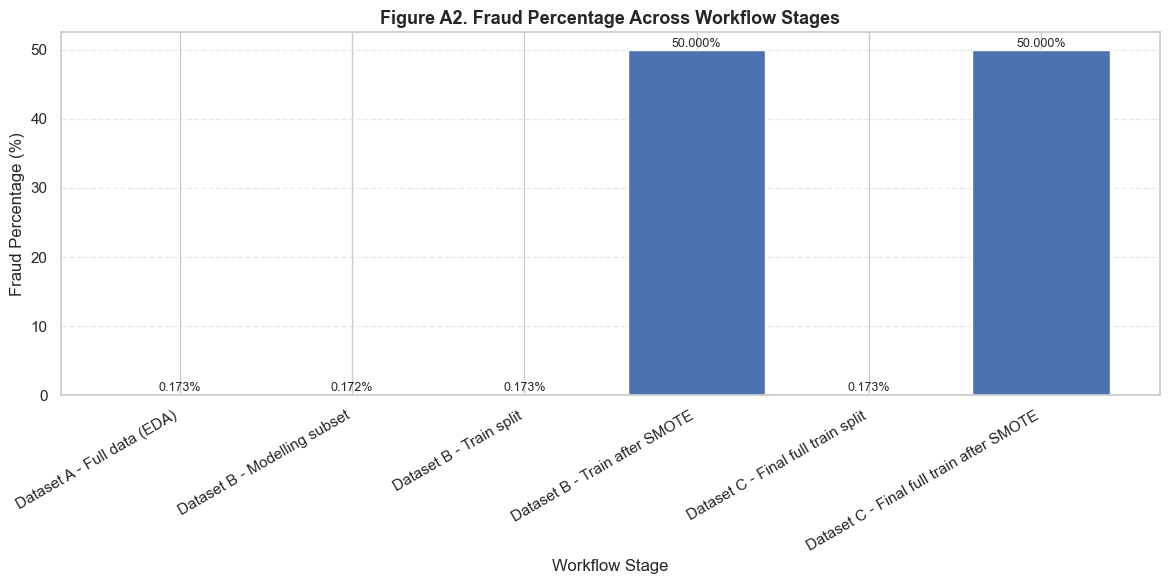

In [29]:
# ============================================================
# 23. DATA FLOW / SAMPLING SUMMARY
# ============================================================

summary_df = pd.DataFrame([
    {
        "Stage": "Dataset A - Full data (EDA)",
        "Rows": len(df_full),
        "Fraud_Cases": int(df_full["Class"].sum()),
        "Fraud_Percent": df_full["Class"].mean() * 100
    },
    {
        "Stage": "Dataset B - Modelling subset",
        "Rows": len(df_model),
        "Fraud_Cases": int(df_model["Class"].sum()),
        "Fraud_Percent": df_model["Class"].mean() * 100
    },
    {
        "Stage": "Dataset B - Train split",
        "Rows": len(y_train),
        "Fraud_Cases": int(y_train.sum()),
        "Fraud_Percent": y_train.mean() * 100
    },
    {
        "Stage": "Dataset B - Train after SMOTE",
        "Rows": len(y_train_smote),
        "Fraud_Cases": int(pd.Series(y_train_smote).sum()),
        "Fraud_Percent": pd.Series(y_train_smote).mean() * 100
    },
    {
        "Stage": "Dataset C - Final full train split",
        "Rows": len(y_train_full),
        "Fraud_Cases": int(y_train_full.sum()),
        "Fraud_Percent": y_train_full.mean() * 100
    },
    {
        "Stage": "Dataset C - Final full train after SMOTE",
        "Rows": len(y_train_full_smote),
        "Fraud_Cases": int(pd.Series(y_train_full_smote).sum()),
        "Fraud_Percent": pd.Series(y_train_full_smote).mean() * 100
    }
])

print("\nData flow summary:")
print(summary_df)

# ============================================================
# Figure A1. Row count across workflow stages
# ============================================================

plt.figure(figsize=(12, 6))
bars = plt.bar(summary_df["Stage"], summary_df["Rows"])

plt.title("Figure A1. Number of Rows Across Workflow Stages", fontsize=13, weight="bold")
plt.xlabel("Workflow Stage")
plt.ylabel("Number of Rows")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "figA1_dataflow_rows_improved.png"), dpi=600)
plt.show()

# ============================================================
# Figure A2. Fraud percentage across workflow stages
# ============================================================

plt.figure(figsize=(12, 6))
bars = plt.bar(summary_df["Stage"], summary_df["Fraud_Percent"])

plt.title("Figure A2. Fraud Percentage Across Workflow Stages", fontsize=13, weight="bold")
plt.xlabel("Workflow Stage")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "figA2_dataflow_fraud_percent_improved.png"), dpi=600)
plt.show()

#### Session finished
---